In [1]:
!python -m pip install pyyaml==5.1
import sys, os, distutils.core
# Note: This is a faster way to install detectron2 in Colab, but it does not include all functionalities (e.g. compiled operators).
# See https://detectron2.readthedocs.io/tutorials/install.html for full installation instructions
!git clone 'https://github.com/facebookresearch/detectron2'
dist = distutils.core.run_setup("./detectron2/setup.py")
!python -m pip install {' '.join([f"'{x}'" for x in dist.install_requires])}
sys.path.insert(0, os.path.abspath('./detectron2'))

# Properly install detectron2. (Please do not install twice in both ways)
# !python -m pip install 'git+https://github.com/facebookresearch/detectron2.git'

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 274.2/274.2 kB 5.4 MB/s eta 0:00:00a 0:00:01
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.
Cloning into 'detectron2'...
remote: Enumerating objects: 15943, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 15943 (delta 5), reused 4 (delta 4), pack-reused 15930 (from 3)
Receiving objects: 100% (15943/15943), 6.70 MiB | 21.23 MiB/s, done.
Resolving deltas: 100% (11337/11337), done.
Ignoring dataclasses: markers 'python_version < "3.7"' don't match you

In [2]:
import os
import cv2
import random
import numpy as np
import torch

In [3]:
from detectron2 import model_zoo
from detectron2.config import get_cfg
from detectron2.engine import DefaultTrainer
from detectron2.data import (DatasetCatalog,MetadataCatalog,build_detection_train_loader,)
from detectron2.data import transforms as T
from detectron2.data.samplers import RepeatFactorTrainingSampler
from detectron2.data.datasets import register_coco_instances
from detectron2.data import DatasetMapper
from detectron2.evaluation import COCOEvaluator
from detectron2.utils.logger import setup_logger
from detectron2.structures import BoxMode

In [4]:
setup_logger()

<Logger detectron2 (DEBUG)>

In [5]:
def properly(img,label):
    dataset=[]
    files=sorted(os.listdir(img))
    for idx,file in enumerate(files):
        record={}
        path=os.path.join(img,file)
        im=cv2.imread(path)
        h,w=im.shape[:2]
        record['file_name']=path
        record['image_id']=idx
        record['height']=h
        record['width']=w
        lpath=os.path.join(label,file.replace('.jpg','.txt'))
        objs=[]
        if os.path.exists(lpath):
            with open(lpath,'r') as f:
                for line in f.readlines():
                    id,xc,yc,wi,he=map(float,line.split())
                    xc*=w
                    yc*=h
                    wi*=w
                    he*=h
                    minx=xc-wi/2
                    miny=yc-he/2
                    maxx=xc+wi/2
                    maxy=yc+he/2
                    obj={
                        'bbox':[minx,miny,maxx,maxy],
                        'bbox_mode':BoxMode.XYXY_ABS,
                        'category_id':int(id),
                        "iscrowd": 0
                    }
                    objs.append(obj)
        record['annotations']=objs
        dataset.append(record)
    return dataset

In [6]:
data=properly('/kaggle/input/urpc2020/URPC2020/train/images','/kaggle/input/urpc2020/URPC2020/train/labels')

In [7]:
DatasetCatalog.register('training01',lambda:properly('/kaggle/input/urpc2020/URPC2020/train/images','/kaggle/input/urpc2020/URPC2020/train/labels'))

In [8]:
MetadataCatalog.get('training01').set(thing_classes=["holothurian", "echinus", "scallop", "starfish"])

namespace(name='training01',
          thing_classes=['holothurian', 'echinus', 'scallop', 'starfish'])

In [9]:
DatasetCatalog.get('training01')[0]

{'file_name': '/kaggle/input/urpc2020/URPC2020/train/images/000001.jpg',
 'image_id': 0,
 'height': 1080,
 'width': 1920,
 'annotations': [{'bbox': [712.0, 415.0, 838.0, 573.0],
   'bbox_mode': <BoxMode.XYXY_ABS: 0>,
   'category_id': 0,
   'iscrowd': 0},
  {'bbox': [128.99999999999997, 940.0000000000001, 300.0, 1081.0],
   'bbox_mode': <BoxMode.XYXY_ABS: 0>,
   'category_id': 1,
   'iscrowd': 0},
  {'bbox': [344.0, 894.0, 467.0, 1002.0],
   'bbox_mode': <BoxMode.XYXY_ABS: 0>,
   'category_id': 1,
   'iscrowd': 0},
  {'bbox': [653.0, 799.0, 792.0, 924.0],
   'bbox_mode': <BoxMode.XYXY_ABS: 0>,
   'category_id': 1,
   'iscrowd': 0},
  {'bbox': [342.0, 540.0, 468.0, 673.0],
   'bbox_mode': <BoxMode.XYXY_ABS: 0>,
   'category_id': 1,
   'iscrowd': 0},
  {'bbox': [1668.0, 251.0, 1833.0, 412.0],
   'bbox_mode': <BoxMode.XYXY_ABS: 0>,
   'category_id': 1,
   'iscrowd': 0}]}

In [10]:
from detectron2.utils.visualizer import Visualizer

In [11]:
sam=data[0]

In [12]:
meta=MetadataCatalog.get('training01')

In [13]:
i=cv2.imread(sam['file_name'])
i=cv2.cvtColor(i,cv2.COLOR_BGR2RGB)

In [14]:
visualizer=Visualizer(i,metadata=meta)
out=visualizer.draw_dataset_dict(sam);

findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
findfont: score(FontEntry(fname='/usr/local/lib/python3.12/dist-packages/matplotlib/mpl-data/fonts/ttf/STIXSizThreeSymReg.ttf', name='STIXSizeThreeSym', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
findfont: score(FontEntry(fname='/usr/local/lib/python3.12/dist-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSansMono-BoldOblique.ttf', name='DejaVu Sans Mono', style='oblique', variant='normal', weight=700, stretch='normal', size='scalable')) = 11.335
findfont: score(FontEntry(fname='/usr/local/lib/python3.12/dist-packages/matplotlib/mpl-data/fonts/ttf/STIXSizOneSymReg.ttf', name='STIXSizeOneSym', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
findfont: score(FontEntry(fname='/usr/local/lib/python3.12/dist-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSerif-Italic.ttf', name='DejaVu Serif', style='italic', v

In [15]:
import matplotlib.pyplot as plt

findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=16.0.
findfont: score(FontEntry(fname='/usr/local/lib/python3.12/dist-packages/matplotlib/mpl-data/fonts/ttf/STIXSizThreeSymReg.ttf', name='STIXSizeThreeSym', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
findfont: score(FontEntry(fname='/usr/local/lib/python3.12/dist-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSansMono-BoldOblique.ttf', name='DejaVu Sans Mono', style='oblique', variant='normal', weight=700, stretch='normal', size='scalable')) = 11.335
findfont: score(FontEntry(fname='/usr/local/lib/python3.12/dist-packages/matplotlib/mpl-data/fonts/ttf/STIXSizOneSymReg.ttf', name='STIXSizeOneSym', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
findfont: score(FontEntry(fname='/usr/local/lib/python3.12/dist-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSerif-Italic.ttf', name='DejaVu Serif', style='italic', v

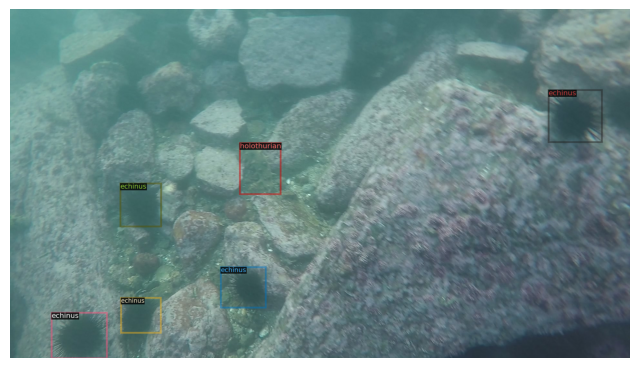

In [16]:
plt.figure(figsize=(8,8));
plt.imshow(out.get_image());
plt.axis("off");
plt.show();

In [17]:
DatasetCatalog.register('val01',lambda:properly('/kaggle/input/urpc2020/URPC2020/valid/images','/kaggle/input/urpc2020/URPC2020/valid/labels'))
DatasetCatalog.register('test01',lambda:properly('/kaggle/input/urpc2020/URPC2020/test/images','/kaggle/input/urpc2020/URPC2020/test/labels'))

In [18]:
MetadataCatalog.get('val01').set(thing_classes=["holothurian", "echinus", "scallop", "starfish"])
MetadataCatalog.get('test01').set(thing_classes=["holothurian", "echinus", "scallop", "starfish"])

namespace(name='test01',
          thing_classes=['holothurian', 'echinus', 'scallop', 'starfish'])

In [19]:
class FixRed(T.Augmentation):
    def __init__(self,mf=0.3,maf=0.8,p=0.5):
        self.mf=mf
        self.maf=maf
        self.p=p
    def get_transform(self,imgs):
        if random.random()>self.p:
            return T.NoOpTransform()
        factor=random.uniform(self.mf,self.maf)
        def red(img):
            img=img.astype(np.float32)
            img[:,:,2]*=factor
            return np.clip(img,0,225).astype(np.uint8)
        return T.ColorTransform(red)

In [20]:
def augment(cfg,is_train=True):
    aug=[]
    if is_train:
        aug=[T.ResizeShortestEdge(
                short_edge_length=(640, 672, 704, 736, 768, 800,1024),
                max_size=1333,
                sample_style="choice",
            ),
            T.RandomFlip(horizontal=True, vertical=False),
            T.RandomBrightness(0.8, 1.2),
            T.RandomContrast(0.8, 1.2),
            T.RandomSaturation(0.8, 1.2),
            FixRed(p=0.5),]
    return DatasetMapper(cfg,is_train=is_train,augmentations=aug)

In [21]:
def oversam(cfg):
    return build_detection_train_loader(cfg,mapper=lambda x:augment(cfg,True))

In [22]:
cnt=torch.tensor([5537,22343,6720,6841],dtype=torch.float32)

In [23]:
wei=1.0/torch.sqrt(cnt)
wei=wei/wei.mean()
wei

tensor([1.2102, 0.6025, 1.0985, 1.0888])

In [24]:
from detectron2.data import get_detection_dataset_dicts

In [25]:
class Train(DefaultTrainer):
    @classmethod
    def build_train_loader(cls, cfg):
        dataset_dicts = get_detection_dataset_dicts(
            cfg.DATASETS.TRAIN,
            filter_empty=cfg.DATALOADER.FILTER_EMPTY_ANNOTATIONS,
            min_keypoints=0, proposal_files=None,
        )
        
        repeat_factors = RepeatFactorTrainingSampler.repeat_factors_from_category_frequency(
            dataset_dicts, cfg.DATALOADER.REPEAT_THRESHOLD
        )
        sampler = RepeatFactorTrainingSampler(repeat_factors)
        my_mapper = augment(cfg, True)
        return build_detection_train_loader(cfg, mapper=my_mapper, sampler=sampler)

    
    @classmethod
    def build_evaluator(cls, cfg, dataset_name, output_folder=None):
        if output_folder is None:
            output_folder = os.path.join(cfg.OUTPUT_DIR, "inference")
        return COCOEvaluator(dataset_name, cfg, False, output_folder)

In [26]:
cfg=get_cfg()

In [27]:
cfg.merge_from_file(model_zoo.get_config_file("COCO-Detection/faster_rcnn_R_101_FPN_3x.yaml"))

In [28]:
cfg.DATASETS.TRAIN=('training01',)
cfg.DATASETS.TEST=('val01',)

In [29]:
cfg.MODEL.ROI_HEADS.NUM_CLASSES=4

In [30]:
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml")

In [31]:
cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 256
cfg.SOLVER.IMS_PER_BATCH = 4
cfg.SOLVER.BASE_LR = 0.001
cfg.SOLVER.MAX_ITER = 3000
cfg.SOLVER.STEPS = (2000, 2600)
cfg.SOLVER.GAMMA = 0.1
cfg.OUTPUT_DIR = "/kaggle/working/output"
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)
cfg.DATALOADER.SAMPLER_TRAIN = "RepeatFactorTrainingSampler"
cfg.DATALOADER.REPEAT_THRESHOLD = 0.01
cfg.TEST.EVAL_PERIOD = 0
cfg.DATALOADER.NUM_WORKERS = 2

In [32]:
trainer = Train(cfg)
trainer.resume_or_load(resume=False)

[01/03 17:20:07 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelMaxPool()
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
      )
      (res

model_final_280758.pkl: 167MB [00:00, 207MB/s]                             

Successfully downloaded /root/.torch/iopath_cache/detectron2/COCO-Detection/faster_rcnn_R_50_FPN_3x/137849458/model_final_280758.pkl. 167266879 bytes.
URL https://dl.fbaipublicfiles.com/detectron2/COCO-Detection/faster_rcnn_R_50_FPN_3x/137849458/model_final_280758.pkl cached in /root/.torch/iopath_cache/detectron2/COCO-Detection/faster_rcnn_R_50_FPN_3x/137849458/model_final_280758.pkl
[Checkpointer] Loading from /root/.torch/iopath_cache/detectron2/COCO-Detection/faster_rcnn_R_50_FPN_3x/137849458/model_final_280758.pkl ...


Reading a file from 'Detectron2 Model Zoo'


Skip loading parameter 'roi_heads.box_predictor.cls_score.weight' to the model due to incompatible shapes: (81, 1024) in the checkpoint but (5, 1024) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.cls_score.bias' to the model due to incompatible shapes: (81,) in the checkpoint but (5,) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.bbox_pred.weight' to the model due to incompatible shapes: (320, 1024) in the checkpoint but (16, 1024) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.bbox_pred.bias' to the model due to incompatible shapes: (320,) in the checkpoint but (16,) in the model! You might want to double check if this is expected.
Some model parameters or buffers are not found in the checkpoint:
backbone.bottom_up.res4.10.conv1.norm.{bias, weight}
backbone.bottom_up.res4.10.conv1.weig

In [ ]:
trainer.train()

[01/03 17:23:00 d2.engine.train_loop]: Starting training from iteration 0


/usr/local/lib/python3.12/dist-packages/torch/functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4322.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


[01/03 17:23:36 d2.utils.events]:  eta: 1:14:17  iter: 19  total_loss: 12.7  loss_cls: 1.775  loss_box_reg: 0.1929  loss_rpn_cls: 8.332  loss_rpn_loc: 1.277    time: 1.4858  last_time: 1.5051  data_time: 0.0357  last_data_time: 0.0103   lr: 1.9981e-05  max_mem: 6470M


2026-01-03 17:23:42.072786: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767461022.618459      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767461022.753061      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767461024.111992      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767461024.112038      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767461024.112041      55 computation_placer.cc:177] computation placer alr

Falling back to TensorFlow client; we recommended you install the Cloud TPU client directly with pip install cloud-tpu-client.
Creating converter from 7 to 5
Creating converter from 5 to 7
Creating converter from 7 to 5
Creating converter from 5 to 7


DEBUG:2026-01-03 17:23:55,136:jax._src.path:41: etils.epath found. Using etils.epath for file I/O.


etils.epath found. Using etils.epath for file I/O.
NumExpr defaulting to 4 threads.
[01/03 17:24:31 d2.utils.events]:  eta: 1:14:32  iter: 39  total_loss: 2.431  loss_cls: 1.385  loss_box_reg: 0.06591  loss_rpn_cls: 0.4389  loss_rpn_loc: 0.1571    time: 1.5116  last_time: 1.3927  data_time: 0.0136  last_data_time: 0.0106   lr: 3.9961e-05  max_mem: 6471M
[01/03 17:25:03 d2.utils.events]:  eta: 1:15:12  iter: 59  total_loss: 0.9308  loss_cls: 0.3909  loss_box_reg: 0.04967  loss_rpn_cls: 0.415  loss_rpn_loc: 0.09005    time: 1.5402  last_time: 1.5481  data_time: 0.0132  last_data_time: 0.0105   lr: 5.9941e-05  max_mem: 8414M
[01/03 17:25:33 d2.utils.events]:  eta: 1:14:48  iter: 79  total_loss: 0.6691  loss_cls: 0.2145  loss_box_reg: 0.07459  loss_rpn_cls: 0.2468  loss_rpn_loc: 0.07602    time: 1.5377  last_time: 1.5315  data_time: 0.0131  last_data_time: 0.0089   lr: 7.9921e-05  max_mem: 8414M
[01/03 17:26:05 d2.utils.events]:  eta: 1:14:34  iter: 99  total_loss: 0.6733  loss_cls: 0.2996

In [ ]:
evaluator = COCOEvaluator(
    "val01",cfg,False,
    output_dir="/kaggle/working/output"
)

In [ ]:
from detectron2.data import build_detection_test_loader

In [ ]:
val_load = build_detection_test_loader(cfg, mapper=lambda x: augment(cfg, False),dataset_name='val01')

In [ ]:
from detectron2.engine import DefaultTrainer

In [ ]:
phal =DefaultTrainer.test(cfg,trainer.model,evaluators=[evaluator])

In [ ]:
phal